<xarray.Dataset> Size: 13MB
Dimensions:        (n: 126, m: 177, corner_n: 127, corner_m: 178, time: 20,
                    timemax: 19, runtime: 1)
Coordinates:
    x              (n, m) float32 89kB ...
    y              (n, m) float32 89kB ...
  * time           (time) datetime64[ns] 160B 2024-09-23 ... 2024-09-27T18:00:00
  * timemax        (timemax) datetime64[ns] 152B 2024-09-23T06:00:00 ... 2024...
Dimensions without coordinates: n, m, corner_n, corner_m, runtime
Data variables: (12/16)
    inp            int32 4B ...
    corner_x       (corner_n, corner_m) float32 90kB ...
    corner_y       (corner_n, corner_m) float32 90kB ...
    crs            int32 4B ...
    hurrywavegrid  int32 4B ...
    msk            (n, m) float32 89kB ...
    ...             ...
    dirspr         (time, n, m) float32 2MB ...
    windspeed      (time, n, m) float32 2MB ...
    waveage        (time, n, m) float32 2MB ...
    hm0max         (timemax, n, m) float32 2MB ...
    total_runtime  (runtime)

C:\Users\csherwood\AppData\Local\miniforge3\envs\CRS\lib\site-packages\cartopy\io\__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


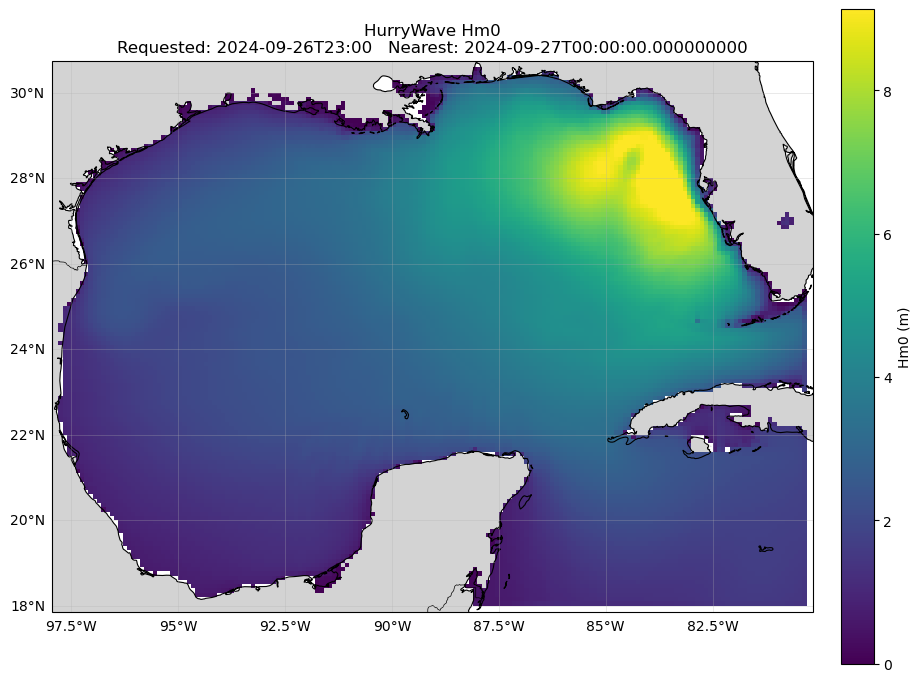

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# Optional, but recommended for map context
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAVE_CARTOPY = True
except ImportError:
    HAVE_CARTOPY = False

# ============================================================
# USER SETTINGS
# ============================================================
ncfile = r"F:/crs/proj/2025_NOPP_comparison/helene_deltares_wave_model_output/helene89pervmax/hurrywave_map.nc"
target_time = np.datetime64("2024-09-26T23:00")

# Plot settings
vmin = 0.0
vmax = None          # set to a float if you want a fixed upper limit, e.g. 8.0
cmap = "viridis"     # or "turbo", "plasma", etc.

# ============================================================
# OPEN DATA
# ============================================================
ds = xr.open_dataset(ncfile)

print(ds)
print("\nAvailable times:")
print(ds["time"].values)

# ============================================================
# SELECT NEAREST TIME
# ============================================================
itime = ds.indexes["time"].get_indexer([target_time], method="nearest")[0]
tsel = ds["time"].values[itime]

print(f"\nRequested time: {target_time}")
print(f"Nearest model time used: {tsel}")

# ============================================================
# EXTRACT VARIABLES
# ============================================================
hm0 = ds["hm0"].isel(time=itime).values          # (n, m)
x = ds["x"].values                               # (n, m) face centers (lon)
y = ds["y"].values                               # (n, m) face centers (lat)
corner_x = ds["corner_x"].values                 # (n+1, m+1)
corner_y = ds["corner_y"].values                 # (n+1, m+1)
msk = ds["msk"].values if "msk" in ds else None  # (n, m)

# ============================================================
# MASK INVALID CELLS
# ============================================================
hm0_plot = hm0.copy()

# Common assumption for Deltares grids:
# msk > 0 are active cells, msk <= 0 inactive.
if msk is not None:
    hm0_plot = np.where(msk > 0, hm0_plot, np.nan)

# Also mask non-finite values
hm0_plot = np.where(np.isfinite(hm0_plot), hm0_plot, np.nan)

# ============================================================
# AUTO LIMITS
# ============================================================
if vmax is None:
    vmax = np.nanpercentile(hm0_plot, 99)

# ============================================================
# PLOT
# ============================================================
fig = plt.figure(figsize=(10, 8))

if HAVE_CARTOPY:
    ax = plt.axes(projection=ccrs.PlateCarree())

    pc = ax.pcolormesh(
        corner_x,
        corner_y,
        hm0_plot,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        shading="flat",
        transform=ccrs.PlateCarree(),
    )

    ax.coastlines(resolution="10m", linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    # Zoom to valid data extent
    valid = np.isfinite(hm0_plot)
    if np.any(valid):
        lon_valid = x[valid]
        lat_valid = y[valid]
        pad_x = 0.2
        pad_y = 0.2
        ax.set_extent([
            np.nanmin(lon_valid) - pad_x,
            np.nanmax(lon_valid) + pad_x,
            np.nanmin(lat_valid) - pad_y,
            np.nanmax(lat_valid) + pad_y,
        ], crs=ccrs.PlateCarree())

else:
    ax = plt.axes()

    pc = ax.pcolormesh(
        corner_x,
        corner_y,
        hm0_plot,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        shading="flat",
    )

    ax.set_xlabel("Longitude (degrees)")
    ax.set_ylabel("Latitude (degrees)")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)

# ============================================================
# COLORBAR / TITLES
# ============================================================
cbar = plt.colorbar(pc, ax=ax, shrink=0.85, pad=0.03)
cbar.set_label("Hm0 (m)")

ax.set_title(f"HurryWave Hm0\nRequested: {target_time}   Nearest: {str(tsel)}")

plt.tight_layout()
plt.show()